In [1]:
from tqdm import tqdm

In [2]:
import mlflow

mlflow.set_tracking_uri("http://35.200.137.114:5000/")
with mlflow.start_run():
    mlflow.log_param("param",15)
    mlflow.log_metric("metric1",0.89)


🏃 View run bemused-fowl-315 at: http://35.200.137.114:5000/#/experiments/0/runs/7e04c9c18110407786fd395d1343aaca
🧪 View experiment at: http://35.200.137.114:5000/#/experiments/0


In [3]:
# creating baseline model

import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [5]:
# drop the null values
print(f"{df.isnull().sum()}")
print("null values cleand")
df.dropna(inplace=True)

clean_comment    100
category           0
dtype: int64
null values cleand


In [6]:
# drop duplicate
print(f"duplicated values : {df.duplicated().sum()} cleaned")
df.drop_duplicates(inplace=True)

duplicated values : 350 cleaned


In [7]:
# strip the white spaces
df = df[~(df['clean_comment'].str.strip() == '')]

In [8]:
# import nltk libs
import regex as re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
# downloaded NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /home/breezy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/breezy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
import regex as re
import pandas as pd
from joblib import Parallel, delayed
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import multiprocessing


lemmatizer = WordNetLemmatizer()

negation_words = {
    'no', 'nor', 'not', 'ain', 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'don', "don't", 'hadn', "hadn't",
    'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn',
    "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan',
    "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren',
    "weren't", 'won', "won't", 'wouldn', "wouldn't",
    'but', 'against', 'however', 'yet'
}

custom_stopwords = set(stopwords.words('english')) - negation_words



# complex regex
NON_ASCII_PATTERN = re.compile(r'[^\x00-\x7F\p{Emoji}\p{Sc}]')
CLEAN_PATTERN = re.compile(r"[^a-z0-9\s!?.,'\p{Emoji}\p{Sc}]")
NEWLINE_PATTERN = re.compile(r'\n+')
MULTISPACE_PATTERN = re.compile(r'\s+')


# main clean function
def clean_and_preprocess_comment(comment):

    # Handle missing values
    if not isinstance(comment, str):
        return ""

    # remove unwanted characters
    comment = NON_ASCII_PATTERN.sub('', comment)
    # lowercase
    comment = comment.lower()
    # remove newlines
    comment = NEWLINE_PATTERN.sub(' ', comment)
    # keep apostrophes
    comment = CLEAN_PATTERN.sub('', comment)
    # tokenize
    words = comment.split()

    # remove stopwords + lemmatize
    cleaned_words = []
    append_word = cleaned_words.append
    stop_words = custom_stopwords
    lemma = lemmatizer.lemmatize

    for word in words:
        if word not in stop_words:
            append_word(lemma(word))

    # join back
    comment = ' '.join(cleaned_words)

    # remove extra spaces
    comment = MULTISPACE_PATTERN.sub(' ', comment).strip()

    return comment



# parallel processing
def parallel_preprocess(series, n_jobs=-1):

    processed = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        batch_size=1000
    )(
        delayed(clean_and_preprocess_comment)(text)
        for text in series
    )

    return pd.Series(processed, index=series.index)


# uses all CPU cores
df['fully_clean_comment'] = parallel_preprocess(df['clean_comment'])

In [11]:
df['fully_clean_comment'].head()

0    family mormon never tried explain still stare ...
1    buddhism much lot compatible christianity espe...
2    seriously don say thing first won get complex ...
3    learned want teach different focus goal not wr...
4    benefit may want read living buddha living chr...
Name: fully_clean_comment, dtype: object

### baseline model making

In [12]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [13]:
# vectorization
vectorizer = CountVectorizer(max_features=10000) # bag of word limit

In [14]:
# separate features and labels
X = df['fully_clean_comment']
y = df['category']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
# vectorize the X_train
X_train_vec= vectorizer.fit_transform(X_train).toarray()

In [17]:
# vectorize the X_test only transform
X_test_vec= vectorizer.transform(X_test).toarray()

In [18]:
# setting up mlflow track this add uri and name of the experiment

mlflow.set_tracking_uri("http://35.200.137.114:5000/")
mlflow.set_experiment("RF Baseline")

<Experiment: artifact_location='gs://mlflow-bucket-01/1', creation_time=1779121042204, experiment_id='1', last_update_time=1779121042204, lifecycle_stage='active', name='RF Baseline', tags={}, trace_location=None, workspace='default'>

2026/05/19 09:19:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_Baseline_TrainTestSplit at: http://35.200.137.114:5000/#/experiments/1/runs/627984ba17154df8af90efdac6407840
🧪 View experiment at: http://35.200.137.114:5000/#/experiments/1
Accuracy: 0.6502242152466368


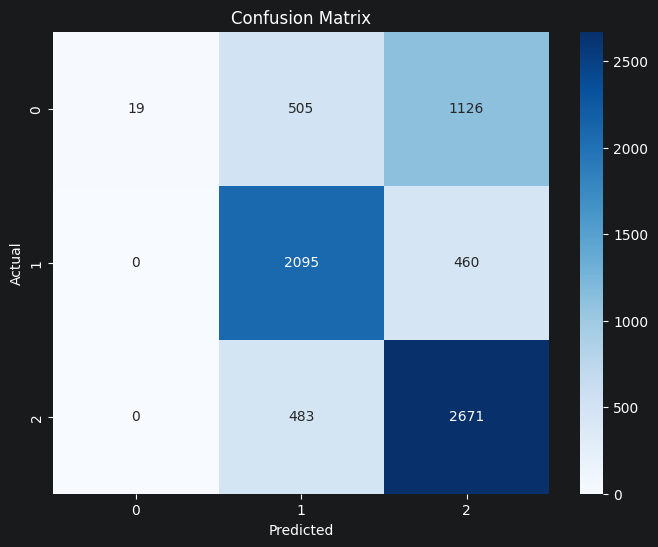

In [21]:
# define and train a random forest baseline model
with mlflow.start_run() as run:
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split")

    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)
    # log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # setting up and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,random_state=42)
    model.fit(X_train_vec, y_train)
    # make the predictions on the test set
    y_pred = model.predict(X_test_vec)

    # Log metrics for each class
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    os.makedirs("content", exist_ok=True)

    plt.savefig("content/confusion_matrix.png")
    mlflow.log_artifact("content/confusion_matrix.png")

    mlflow.sklearn.log_model(model, name="random_forest_model")

    df.to_csv("content/dataset.csv", index=False)
    mlflow.log_artifact("content/dataset.csv")
print(f"Accuracy: {accuracy}")

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.01      0.02      1650
           0       0.68      0.82      0.74      2555
           1       0.63      0.85      0.72      3154

    accuracy                           0.65      7359
   macro avg       0.77      0.56      0.50      7359
weighted avg       0.73      0.65      0.57      7359



In [24]:
df.to_csv('reddit_preprocessing.csv', index=False)

In [25]:
pd.read_csv('reddit_preprocessing.csv').head()

,clean_comment,category,fully_clean_comment
0,family mormon have never tried explain them t...,1,family mormon never tried explain still stare ...
1,buddhism has very much lot compatible with chr...,1,buddhism much lot compatible christianity espe...
2,seriously don say thing first all they won get...,-1,seriously don say thing first won get complex ...
3,what you have learned yours and only yours wha...,0,learned want teach different focus goal not wr...
4,for your own benefit you may want read living ...,1,benefit may want read living buddha living chr...
